# P2 - Regression Modeling (Flight Delays)
**Dataset:** Türkiye flights + weather (turkiye_ucuslari_final.csv)

[GitHub Repository](https://github.com/dincerefe/machinelearning_yzm2011/tree/main)



In [2]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, Ridge, Lasso, LogisticRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'legend.fontsize': 10})
SEED = 42
print('All libraries loaded.')


All libraries loaded.


---

## 1. Recap & Motivation

I analyzed a flight dataset with approximately 670k records collected from flightera.net and combined  it data hourly weather and aircraft information from flightaware. Each row is a flight in Turkey with schedule, carrier, route, aircraft, and departure/arrival weather. 

**Regression Target:** `departure_delay_min` which represents how many minutes a flight departs late or early relative to schedule.


The main P1 findings were that delays increase later in the day, differ across airlines and routes, and become worse under disruptive weather, so the modeling choices here focus on pre-departure schedule signals, airport traffic, airline and airport context, and weather features. We avoid using any information that would only be known after the flight has already departed.

In [3]:
df = pd.read_csv('turkiye_ucuslari_final.csv')
print('Shape:', df.shape)
df.head()


Shape: (668274, 38)


,date,departure_airport,departure_city,arrival_airport,arrival_info,airline,flight_number,scheduled_departure,actual_departure,arrival_time,...,arr_temperature,arr_humidity,arr_precipitation_mm,arr_wind_speed,arr_wind_gust,arr_visibility_min_m,arr_cloud_cover,actual_flight_duration_min,average_flight_duration_min,arrival_delay_min
0,2024-01-01,KYA,Konya,DUS,Dusseldorf(DUS / EDDL),SunExpress,XQ1326,04:30,04:46,06:15,...,6.5,84.0,0.5,24.6,47.5,NaN,NaN,208.0,207.5,16.5
1,2024-01-01,KYA,Konya,SAW,Istanbul(SAW / LTFJ),Turkish Airlines,TK7283,08:20,12:13,13:07,...,13.9,65.0,0.0,11.9,24.5,NaN,97.0,54.0,55.0,232.0
2,2024-01-01,KYA,Konya,IST,Istanbul(IST / LTFM),Turkish Airlines,TK2033,09:50,09:57,11:20,...,11.9,83.0,0.0,14.2,25.9,NaN,62.0,90.0,60.0,37.0
3,2024-01-01,KYA,Konya,IST,Istanbul(IST / LTFM),Turkish Airlines,TK2037,16:20,16:21,17:34,...,14.4,76.0,0.0,16.1,29.9,NaN,87.0,73.0,60.0,14.0
4,2024-01-01,KYA,Konya,IST,Istanbul(IST / LTFM),Turkish Airlines,TK6951,17:05,17:09,18:11,...,13.4,80.0,0.0,18.0,31.0,NaN,97.0,62.0,60.0,6.0


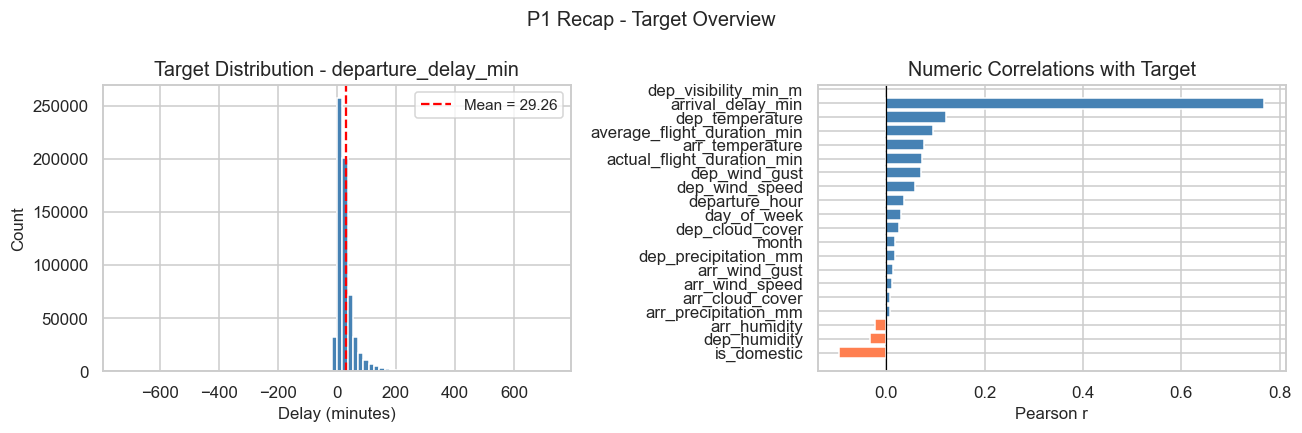

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
delay = df['departure_delay_min'].dropna()
axes[0].hist(delay, bins=80, color='steelblue', edgecolor='white')
axes[0].axvline(delay.mean(), color='red', linestyle='--',
                label=f"Mean = {delay.mean():.2f}")
axes[0].set_title('Target Distribution - departure_delay_min')
axes[0].set_xlabel('Delay (minutes)'); axes[0].set_ylabel('Count'); axes[0].legend()

num_cols = df.select_dtypes(include=[np.number]).columns
corrs = df[num_cols].corr()['departure_delay_min'].drop('departure_delay_min').sort_values()
colors = ['coral' if c < 0 else 'steelblue' for c in corrs]
axes[1].barh(corrs.index, corrs.values, color=colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Numeric Correlations with Target'); axes[1].set_xlabel('Pearson r')

plt.suptitle('P1 Recap - Target Overview', fontsize=13); plt.tight_layout(); plt.show()


---
## 2. Feature Engineering

New features aligned with aviation logic (knock-on effects, traffic, seasonality, thresholds):

| # | Feature | Technique | Rationale |
|---|---|---|---|
| 1 | `dep_airport_delay_3h` | Rolling window | Avg delay in last 3 hours at the departure airport (knock-on effect) |
| 2 | `dep_traffic_volume` | Aggregation | Hourly traffic volume at departure airport |
| 3 | `arr_traffic_volume` | Aggregation | Hourly traffic volume at arrival airport (proxy) |
| 4 | `is_holiday`, `is_eid`, `is_new_year`, `is_school_break` | Seasonality | Feast, New year, and holiday traffic effects |
| 5 | `is_windy`, `is_gusty`, `is_heavy_precip`, `is_low_visibility` | Thresholds | Critical weather conditions (binary) |
| 6 | `arr_*` weather features | Enrichment | Arrival weather affects slot and holding decisions |
| 7 | `scheduled_dep_minutes`, `is_weekend` | Datetime decomposition | Captures time-of-day and weekend effects |
| 8 | `tail_flight_seq`, `tail_daily_flights` (if tail number exists) | Aggregation | Aircraft rotation depth for the day |


In [5]:
df_feat = df.copy()
df_feat = df_feat.drop_duplicates()

df_feat['date'] = pd.to_datetime(df_feat['date'], errors='coerce')
df_feat = df_feat.dropna(subset=['date', 'departure_delay_min'])

# Normalize airline labels
df_feat['airline'] = df_feat['airline'].astype(str).str.strip().str.upper()
df_feat.loc[df_feat['airline'] == 'VALUAIR', 'airline'] = 'AJET'

# Normalize time_slot labels
time_slot_map = {'Sabah': 'Morning', 'Ogle': 'Afternoon', 'Aksam': 'Evening', 'Gece': 'Night'}
if 'time_slot' in df_feat.columns:
    df_feat['time_slot'] = df_feat['time_slot'].replace(time_slot_map)

# Scheduled departure timestamp
df_feat['scheduled_dep_ts'] = pd.to_datetime(
    df_feat['date'].dt.strftime('%Y-%m-%d') + ' ' + df_feat['scheduled_departure'],
    errors='coerce'
 )
df_feat = df_feat.dropna(subset=['scheduled_dep_ts'])

# Remove cancelled flights
cancel_mask = df_feat['status'].eq('Cancelled') | df_feat['status_category'].eq('Cancelled')
df_feat = df_feat.loc[~cancel_mask].copy()

# Time features
df_feat['departure_hour'] = df_feat['scheduled_dep_ts'].dt.hour
df_feat['scheduled_dep_minutes'] = df_feat['scheduled_dep_ts'].dt.hour * 60 + df_feat['scheduled_dep_ts'].dt.minute
df_feat['is_weekend'] = df_feat['scheduled_dep_ts'].dt.dayofweek.isin([5, 6]).astype(int)

# Holiday features
years = sorted(df_feat['date'].dt.year.dropna().unique())
fixed_holidays = [(1, 1), (4, 23), (5, 1), (5, 19), (7, 15), (8, 30), (10, 29)]
holiday_dates = [pd.Timestamp(y, m, d) for y in years for (m, d) in fixed_holidays]

religious = pd.to_datetime([
    '2023-04-21','2023-04-22','2023-04-23',
    '2023-06-28','2023-06-29','2023-06-30','2023-07-01',
    '2024-04-10','2024-04-11','2024-04-12',
    '2024-06-16','2024-06-17','2024-06-18','2024-06-19'
], errors='coerce')

holiday_dates = pd.to_datetime(holiday_dates + list(religious.dropna()))

df_feat['is_holiday'] = df_feat['date'].isin(holiday_dates).astype(int)
df_feat['is_new_year'] = ((df_feat['date'].dt.month == 1) & (df_feat['date'].dt.day == 1)).astype(int)
df_feat['is_eid'] = df_feat['date'].isin(religious).astype(int)
df_feat['is_school_break'] = df_feat['date'].dt.month.isin([6, 7, 8]).astype(int)

# Traffic volume
df_feat['dep_hour_bucket'] = df_feat['scheduled_dep_ts'].dt.floor('h')
df_feat['dep_traffic_volume'] = df_feat.groupby(['departure_airport', 'dep_hour_bucket'])['flight_number'].transform('count')
df_feat['arr_traffic_volume'] = df_feat.groupby(['arrival_airport', 'dep_hour_bucket'])['flight_number'].transform('count')

# Rolling window: last 3 hours delay at departure airport
def add_rolling(group):
    group = group.sort_values('scheduled_dep_ts')
    group['dep_airport_delay_3h'] = (
        group.set_index('scheduled_dep_ts')['departure_delay_min']
             .rolling('3h', closed='left').mean()
             .reset_index(drop=True)
    )
    return group

df_feat = df_feat.groupby('departure_airport', group_keys=False).apply(add_rolling)
df_feat['dep_airport_delay_3h'] = df_feat['dep_airport_delay_3h'].fillna(df_feat['departure_delay_min'].mean())

# Weather thresholds (adjust thresholds if units differ)
def add_threshold(col, thr, new_col, le=False):
    if col in df_feat.columns:
        if le:
            df_feat[new_col] = (df_feat[col] <= thr).astype(int)
        else:
            df_feat[new_col] = (df_feat[col] >= thr).astype(int)

add_threshold('dep_wind_speed', 20.6, 'is_windy')
add_threshold('dep_wind_gust', 25.0, 'is_gusty')
add_threshold('dep_precipitation_mm', 5.0, 'is_heavy_precip')
add_threshold('dep_visibility_min_m', 2000, 'is_low_visibility', le=True)
add_threshold('arr_wind_gust', 25.0, 'arr_is_gusty')

# Log transforms for skewed precipitation
if 'dep_precipitation_mm' in df_feat.columns:
    df_feat['log_dep_precip'] = np.log1p(df_feat['dep_precipitation_mm'].clip(lower=0))
if 'arr_precipitation_mm' in df_feat.columns:
    df_feat['log_arr_precip'] = np.log1p(df_feat['arr_precipitation_mm'].clip(lower=0))


engineered = [c for c in df_feat.columns if c not in df.columns]
print('Engineered features:', engineered)
print('Rows:', len(df_feat), 'Columns:', df_feat.shape[1])
df_feat.head()


Engineered features: ['scheduled_dep_ts', 'scheduled_dep_minutes', 'is_weekend', 'is_holiday', 'is_new_year', 'is_eid', 'is_school_break', 'dep_hour_bucket', 'dep_traffic_volume', 'arr_traffic_volume', 'dep_airport_delay_3h', 'is_windy', 'is_gusty', 'is_heavy_precip', 'is_low_visibility', 'arr_is_gusty', 'log_dep_precip', 'log_arr_precip']
Rows: 605675 Columns: 55


,date,departure_city,arrival_airport,arrival_info,airline,flight_number,scheduled_departure,actual_departure,arrival_time,flight_duration,...,dep_traffic_volume,arr_traffic_volume,dep_airport_delay_3h,is_windy,is_gusty,is_heavy_precip,is_low_visibility,arr_is_gusty,log_dep_precip,log_arr_precip
139,2024-01-01,Gaziemir,IST,Istanbul(IST / LTFM),TURKISH AIRLINES,TK2341,00:05,00:14,01:01,47m,...,1,2,23.000000,0,0,0,0,0,0.0,0.0
60,2024-01-01,Gaziemir,IST,Istanbul(IST / LTFM),TURKISH AIRLINES,TK2349,04:30,04:33,05:18,44m,...,3,10,9.363636,0,0,0,0,0,0.0,0.0
61,2024-01-01,Gaziemir,BRU,Brussels(BRU / EBBR),SUNEXPRESS,XQ932,04:45,04:57,06:11,3h 13m,...,3,1,10.300000,0,0,0,0,1,0.0,0.0
141,2024-01-01,Gaziemir,SAW,Istanbul(SAW / LTFJ),TURKISH AIRLINES,TK7511,04:45,04:45,05:55,1h 10m,...,3,2,33.600000,0,0,0,0,0,0.0,0.0
142,2024-01-01,Gaziemir,DIY,Diyarbakir(DIY / LTCC),SUNEXPRESS,XQ9192,05:00,06:58,08:32,1h 33m,...,3,1,29.600000,0,0,0,0,0,0.0,0.0


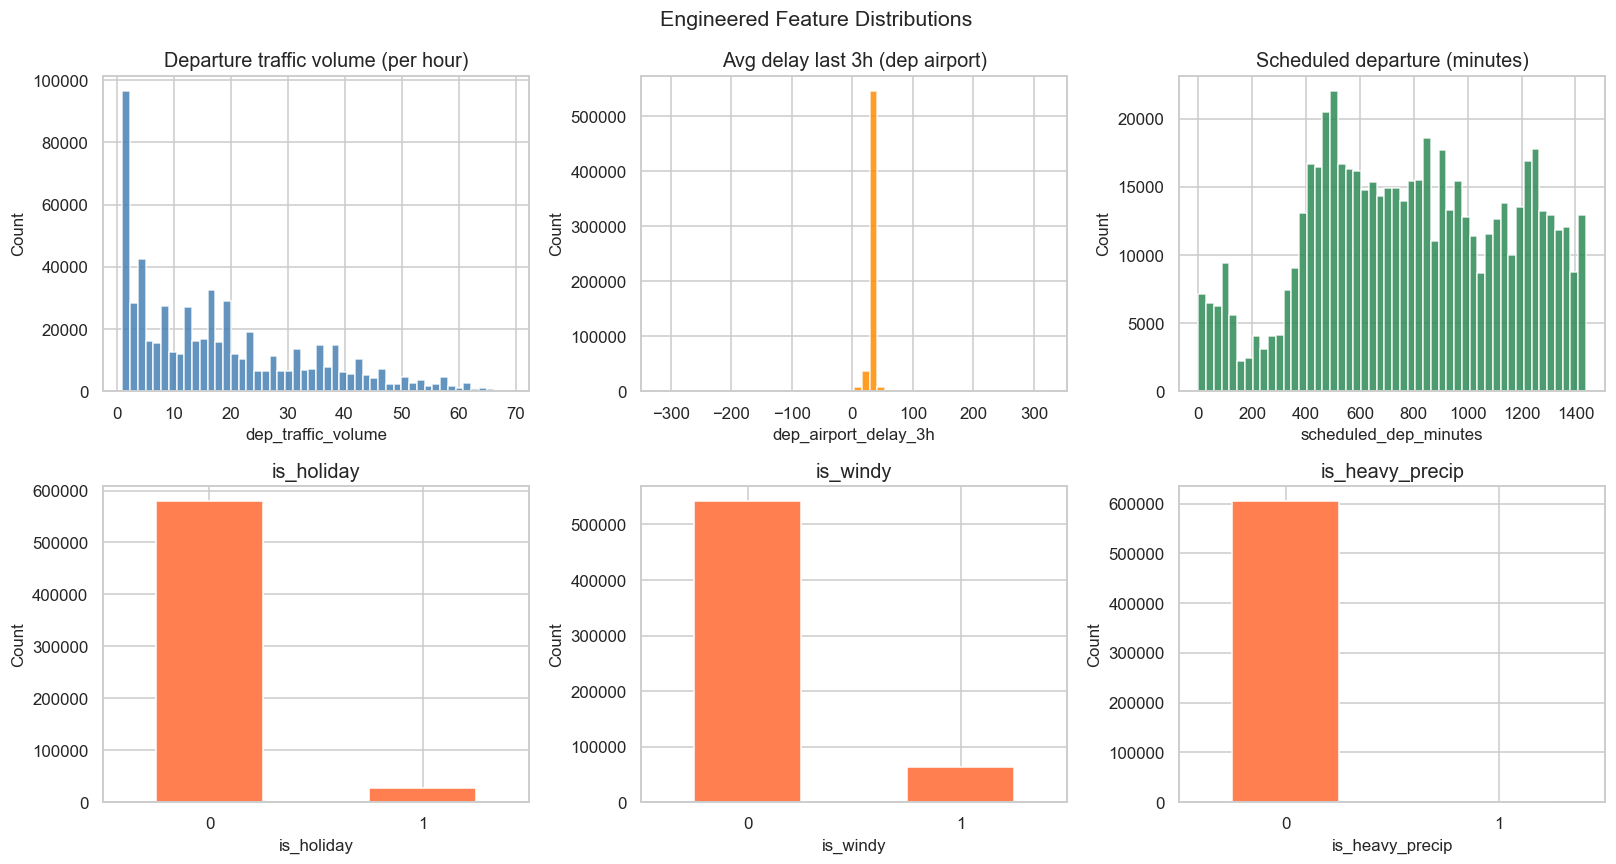

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8)); axes = axes.flatten()
plot_defs = [
    ('dep_traffic_volume', 'Departure traffic volume (per hour)', 'steelblue'),
    ('dep_airport_delay_3h', 'Avg delay last 3h (dep airport)', 'darkorange'),
    ('scheduled_dep_minutes', 'Scheduled departure (minutes)', 'seagreen')
 ]

for i, (col, title, color) in enumerate(plot_defs):
    if col in df_feat.columns:
        axes[i].hist(df_feat[col].dropna(), bins=50, color=color, edgecolor='white', alpha=0.85)
        axes[i].set_title(title); axes[i].set_xlabel(col); axes[i].set_ylabel('Count')
    else:
        axes[i].axis('off')

bin_cols = ['is_holiday', 'is_windy', 'is_heavy_precip']
for j, col in enumerate(bin_cols):
    ax = axes[len(plot_defs) + j]
    if col in df_feat.columns:
        df_feat[col].value_counts().sort_index().plot(kind='bar', ax=ax, color='coral', edgecolor='white')
        ax.set_title(col); ax.set_xlabel(col); ax.set_ylabel('Count'); ax.tick_params(axis='x', rotation=0)
    else:
        ax.axis('off')

plt.suptitle('Engineered Feature Distributions', fontsize=14); plt.tight_layout(); plt.show()


---
## 3. Train / Validation / Test Split

**60 % train · 20 % validation · 20 % test** by chronological order.
This is important because rolling-window features use past flights; a time-based split reduces leakage.

**Scaling:** `StandardScaler` is fit only on the training split inside pipelines, then applied to val/test.

In [7]:
target_col = 'departure_delay_min'

# Drop columns that would leak post-departure info
leak_cols = [
    'actual_departure', 'arrival_time', 'arrival_delay_min',
    'actual_flight_duration_min', 'flight_duration', 'status', 'status_category'
 ]
df_feat = df_feat.drop(columns=[c for c in leak_cols if c in df_feat.columns])

# Time-based split to avoid leakage with rolling features
df_feat = df_feat.sort_values('scheduled_dep_ts').reset_index(drop=True)
n = len(df_feat)
train_end = int(n * 0.6)
val_end = int(n * 0.8)

train_df = df_feat.iloc[:train_end].copy()
val_df = df_feat.iloc[train_end:val_end].copy()
test_df = df_feat.iloc[val_end:].copy()

print(f'Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}')

numeric_features = [
    'departure_hour', 'month', 'day_of_week', 'is_domestic',
    'dep_temperature', 'dep_humidity', 'dep_precipitation_mm',
    'dep_wind_speed', 'dep_wind_gust', 'average_flight_duration_min',
    'scheduled_dep_minutes', 'is_weekend',
    'dep_traffic_volume', 'arr_traffic_volume', 'dep_airport_delay_3h',
    'is_holiday', 'is_new_year', 'is_eid', 'is_school_break',
    'is_windy', 'is_gusty', 'is_heavy_precip', 'is_low_visibility',
    'arr_temperature', 'arr_humidity', 'arr_precipitation_mm',
    'arr_wind_speed', 'arr_wind_gust', 'arr_is_gusty',
    'log_dep_precip', 'log_arr_precip'
 ]
tail_features = [c for c in ['tail_flight_seq', 'tail_daily_flights'] if c in df_feat.columns]
numeric_features = [c for c in numeric_features if c in df_feat.columns] + tail_features

categorical_features = [
    c for c in ['airline', 'aircraft_type', 'departure_airport', 'arrival_airport', 'time_slot', 'day_name']
    if c in df_feat.columns
 ]

features = numeric_features + categorical_features

X_train = train_df[features]
y_train = train_df[target_col]
X_val = val_df[features]
y_val = val_df[target_col]
X_test = test_df[features]
y_test = test_df[target_col]

print('Numeric features:', len(numeric_features), '| Categorical features:', len(categorical_features))

def regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {
        'r2': r2_score(y_true, y_pred),
        'rmse': rmse,
        'mae': mean_absolute_error(y_true, y_pred),
    }

def eval_model(model, X, y):
    preds = model.predict(X)
    return preds, regression_metrics(y, preds)

model_scores = {}
model_store = {}

def add_scores(name, train_m, val_m, test_m, model):
    model_scores[name] = {
        'Train_R2': train_m['r2'],
        'Val_R2': val_m['r2'],
        'Test_R2': test_m['r2'],
        'Test_RMSE': test_m['rmse'],
        'Test_MAE': test_m['mae'],
    }
    model_store[name] = model


Train: 363,405  Val: 121,135  Test: 121,135
Numeric features: 31 | Categorical features: 5


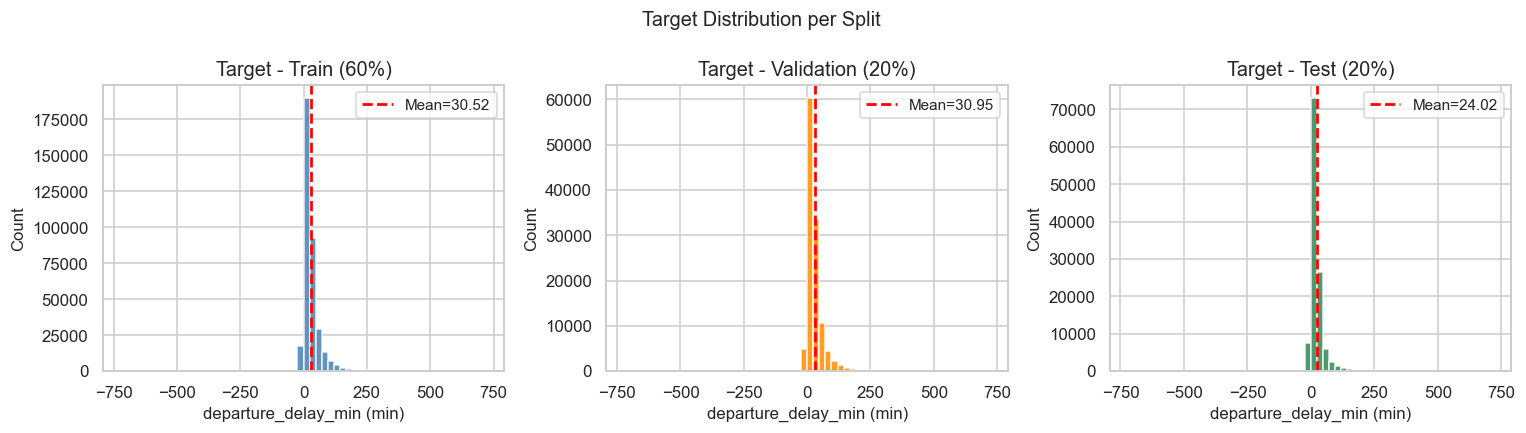

,N,Mean,Std
Split,,,
Train,363405,30.522,53.925
Val,121135,30.948,52.313
Test,121135,24.023,61.052


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, ysplit, label, color in zip(
        axes,
        [y_train, y_val, y_test],
        ['Train (60%)', 'Validation (20%)', 'Test (20%)'],
        ['steelblue', 'darkorange', 'seagreen']):
    ax.hist(ysplit, bins=60, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(ysplit.mean(), color='red', linewidth=1.8, linestyle='--', label=f'Mean={ysplit.mean():.2f}')
    ax.set_title(f'Target - {label}'); ax.set_xlabel('departure_delay_min (min)'); ax.set_ylabel('Count'); ax.legend()
plt.suptitle('Target Distribution per Split', fontsize=13); plt.tight_layout(); plt.show()

pd.DataFrame({
    'Split': ['Train', 'Val', 'Test'],
    'N': [len(y_train), len(y_val), len(y_test)],
    'Mean': [y_train.mean(), y_val.mean(), y_test.mean()],
    'Std': [y_train.std(), y_val.std(), y_test.std()]
}).set_index('Split').round(3)


---
## 4. Baseline Model 



In [9]:
corrs = train_df[numeric_features + [target_col]].corr()[target_col].drop(target_col).abs().sort_values(ascending=False)
baseline_feature = corrs.index[0]
print('Baseline feature:', baseline_feature)

baseline_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LinearRegression()),
])

baseline_pipe.fit(X_train[[baseline_feature]], y_train)

train_pred, train_m = eval_model(baseline_pipe, X_train[[baseline_feature]], y_train)
val_pred, val_m = eval_model(baseline_pipe, X_val[[baseline_feature]], y_val)
test_pred, test_m = eval_model(baseline_pipe, X_test[[baseline_feature]], y_test)

add_scores('Baseline (simple LR)', train_m, val_m, test_m, baseline_pipe)

print('Train metrics:', train_m)
print('Validation metrics:', val_m)
print('Test metrics:', test_m)


Baseline feature: is_school_break
Train metrics: {'r2': 0.02922380246812517, 'rmse': np.float64(53.13144550400221), 'mae': 25.035020913652236}
Validation metrics: {'r2': -0.01922654527319545, 'rmse': np.float64(52.81343229972974), 'mae': 26.029422070951732}
Test metrics: {'r2': -1.5899015324283283e-06, 'rmse': np.float64(61.05228518995326), 'mae': 23.58755028401131}


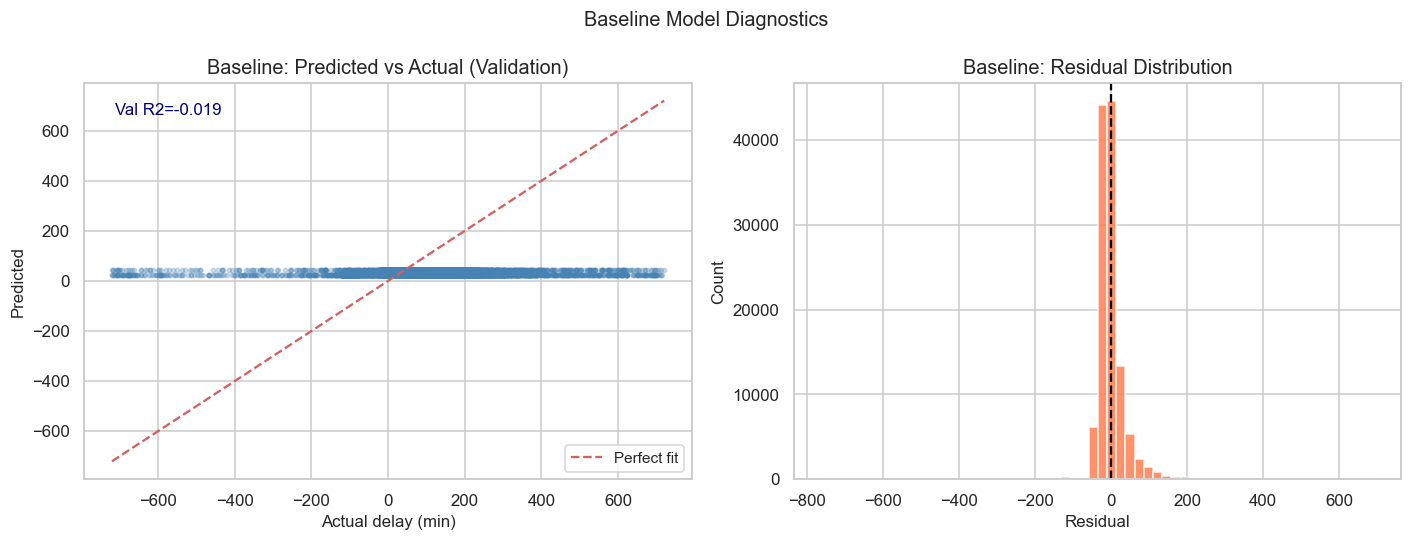

In [10]:
yp_b = baseline_pipe.predict(X_val[[baseline_feature]])
res_b = y_val - yp_b
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_val, yp_b, alpha=0.25, s=8, color='steelblue')
lo, hi = y_val.min(), y_val.max()
axes[0].plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_title('Baseline: Predicted vs Actual (Validation)')
axes[0].set_xlabel('Actual delay (min)'); axes[0].set_ylabel('Predicted'); axes[0].legend()
axes[0].text(0.05, 0.92, f"Val R2={val_m['r2']:.3f}", transform=axes[0].transAxes, fontsize=11, color='navy')
axes[1].hist(res_b, bins=60, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_title('Baseline: Residual Distribution'); axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Count')
plt.suptitle('Baseline Model Diagnostics', fontsize=13); plt.tight_layout(); plt.show()


Baseline performance shows a low-to-moderate R2. A single feature cannot capture traffic, airline differences, or weather interactions. 

---
## 5. Multiple Linear Regression


In [11]:
def make_preprocess():
    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ])
    categorical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])
    return ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features),
        ]
    )

multi_lr = Pipeline([
    ('preprocess', make_preprocess()),
    ('model', LinearRegression()),
])

multi_lr.fit(X_train, y_train)

train_pred, train_m = eval_model(multi_lr, X_train, y_train)
val_pred, val_m = eval_model(multi_lr, X_val, y_val)
test_pred, test_m = eval_model(multi_lr, X_test, y_test)

add_scores('Multiple LR', train_m, val_m, test_m, multi_lr)

print('Train metrics:', train_m)
print('Validation metrics:', val_m)
print('Test metrics:', test_m)


Train metrics: {'r2': 0.07879982057642476, 'rmse': np.float64(51.75699803875711), 'mae': 23.68714977990619}
Validation metrics: {'r2': 0.0025838011869848687, 'rmse': np.float64(52.24530133206071), 'mae': 24.79136816971321}
Test metrics: {'r2': -0.006619504731872006, 'rmse': np.float64(61.253971146219335), 'mae': 22.94152230748344}


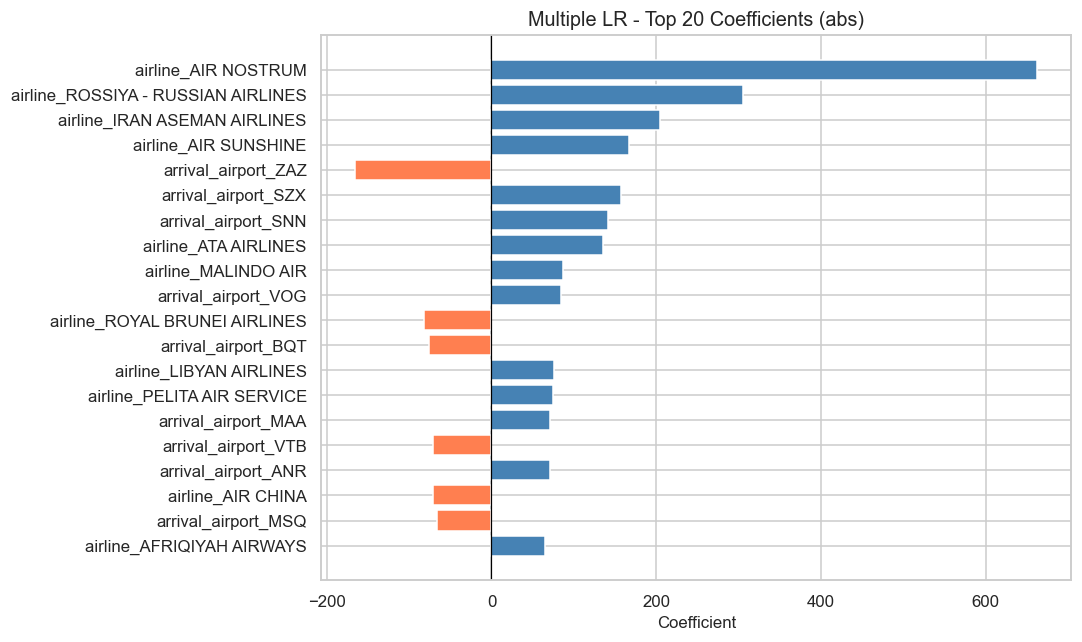

,Feature,Coefficient
47,airline_AIR NOSTRUM,662.4336
146,airline_ROSSIYA - RUSSIAN AIRLINES,304.9442
109,airline_IRAN ASEMAN AIRLINES,204.7195
49,airline_AIR SUNSHINE,166.8293
629,arrival_airport_ZAZ,-165.1443
578,arrival_airport_SZX,157.1710
562,arrival_airport_SNN,141.5024
55,airline_ATA AIRLINES,135.8900
126,airline_MALINDO AIR,87.3971
619,arrival_airport_VOG,84.1805


In [12]:
def get_feature_names(preprocessor):
    feature_names = []
    for name, transformer, cols in preprocessor.transformers_:
        if name == 'remainder':
            continue
        if hasattr(transformer, 'named_steps'):
            last_step = list(transformer.named_steps.values())[-1]
        else:
            last_step = transformer
        if hasattr(last_step, 'get_feature_names_out'):
            names = last_step.get_feature_names_out(cols)
        else:
            names = cols
        feature_names.extend(names)
    return feature_names

feature_names = get_feature_names(multi_lr.named_steps['preprocess'])
coefs = multi_lr.named_steps['model'].coef_
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefs})
coef_df['Abs'] = coef_df['Coefficient'].abs()
top = coef_df.sort_values('Abs', ascending=False).head(20)

colors_c = ['steelblue' if c > 0 else 'coral' for c in top['Coefficient']]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top['Feature'], top['Coefficient'], color=colors_c, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Multiple LR - Top 20 Coefficients (abs)')
ax.set_xlabel('Coefficient'); ax.invert_yaxis()
plt.tight_layout(); plt.show()

top[['Feature', 'Coefficient']].round(4)


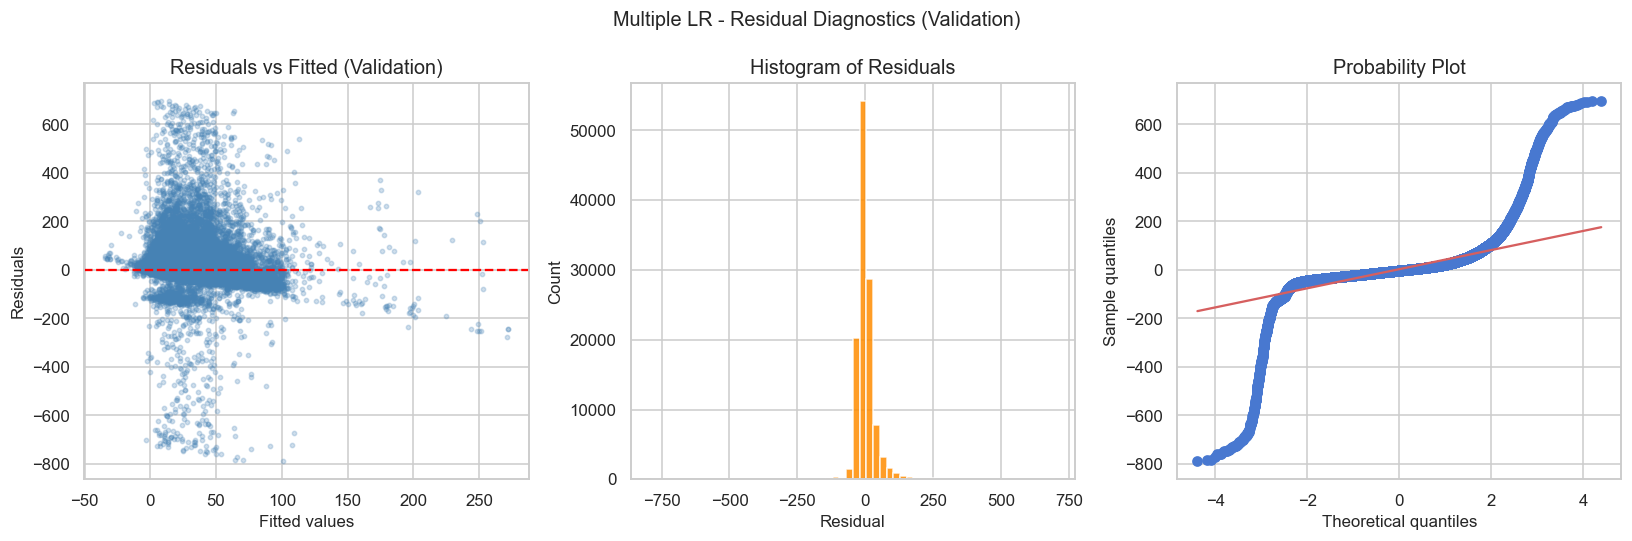

In [13]:
residuals = y_val - val_pred
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].scatter(val_pred, residuals, alpha=0.25, s=8, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals vs Fitted (Validation)')
axes[0].set_xlabel('Fitted values'); axes[0].set_ylabel('Residuals')

axes[1].hist(residuals, bins=60, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_title('Histogram of Residuals'); axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Count')

axes[2].set_title('Q-Q Plot')
try:
    from scipy import stats
    stats.probplot(residuals, dist='norm', plot=axes[2])
    axes[2].set_xlabel('Theoretical quantiles')
    axes[2].set_ylabel('Sample quantiles')
except Exception:
    axes[2].text(0.5, 0.5, 'SciPy not available', ha='center', va='center')
    axes[2].set_xlabel('')
    axes[2].set_ylabel('')

plt.suptitle('Multiple LR - Residual Diagnostics (Validation)', fontsize=13); plt.tight_layout(); plt.show()


**Coefficient highlights:** The largest magnitude coefficients are dominated by specific categorical dummy variables. The model relies heavily on these specific carriers and routes to adjust predictions, rather than continuous flight features.

**Residual plots:** The diagnostics reveal a poor fit for standard linear regression. The histogram displays massive zero-inflation, while the Q-Q plot shows extreme heavy tails. Furthermore, the residuals vs. fitted plot shows non-random clustering, suggesting uncaptured non-linear effects. Later sections will test polynomial expansions and regularized models to address these issues. make this shorter


---
## 6. Polynomial Regression


In [14]:
poly_numeric = [
    'departure_hour', 'scheduled_dep_minutes', 'dep_wind_speed', 'dep_wind_gust',
    'dep_precipitation_mm', 'average_flight_duration_min', 'dep_airport_delay_3h'
 ]
poly_numeric = [c for c in poly_numeric if c in numeric_features]
other_numeric = [c for c in numeric_features if c not in poly_numeric]

poly_results = []
best_poly = None
best_poly_degree = None
best_val_rmse = np.inf
best_poly_metrics = None

for degree in [1, 2, 3]:
    poly_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
    ])
    other_num_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ])
    preprocess_poly = ColumnTransformer(
        transformers=[
            ('poly', poly_transformer, poly_numeric),
            ('num', other_num_transformer, other_numeric),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))
            ]), categorical_features),
        ]
    )

    poly_lr = Pipeline([
        ('preprocess', preprocess_poly),
        ('model', LinearRegression()),
    ])

    poly_lr.fit(X_train, y_train)

    train_pred, train_m = eval_model(poly_lr, X_train, y_train)
    val_pred, val_m = eval_model(poly_lr, X_val, y_val)
    test_pred, test_m = eval_model(poly_lr, X_test, y_test)

    poly_results.append({
        'degree': degree,
        'train_rmse': train_m['rmse'],
        'val_rmse': val_m['rmse'],
    })

    if degree >= 2 and val_m['rmse'] < best_val_rmse:
        best_val_rmse = val_m['rmse']
        best_poly_degree = degree
        best_poly = poly_lr
        best_poly_metrics = (train_m, val_m, test_m)

poly_df = pd.DataFrame(poly_results)
print(poly_df)

if best_poly is not None:
    add_scores(f'Polynomial (deg {best_poly_degree})', best_poly_metrics[0], best_poly_metrics[1], best_poly_metrics[2], best_poly)


   degree  train_rmse   val_rmse
0       1   51.756989  52.245895
1       2   51.730771  52.345428
2       3   51.790279  52.296710


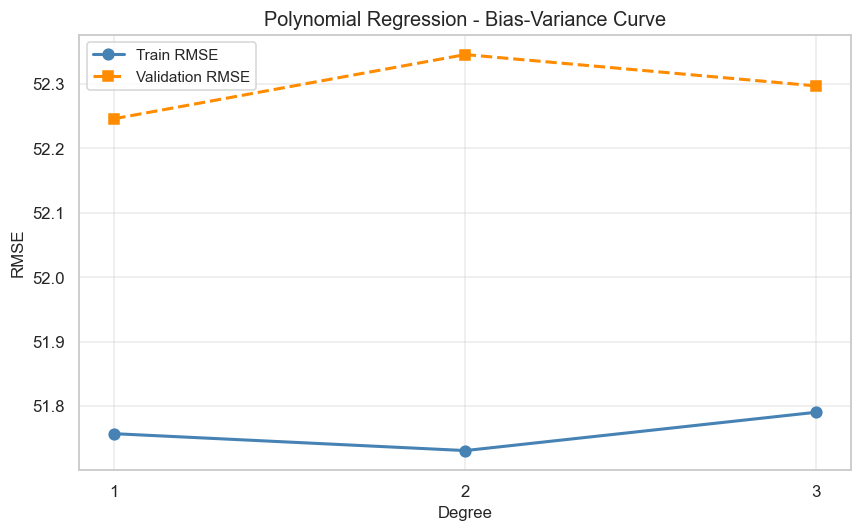

Best degree by validation RMSE (>=2): 3


In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(poly_df['degree'], poly_df['train_rmse'], 'o-', color='steelblue', lw=2, ms=7, label='Train RMSE')
ax.plot(poly_df['degree'], poly_df['val_rmse'], 's--', color='darkorange', lw=2, ms=7, label='Validation RMSE')
ax.set_title('Polynomial Regression - Bias-Variance Curve')
ax.set_xlabel('Degree'); ax.set_ylabel('RMSE')
ax.set_xticks(poly_df['degree']); ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()
print('Best degree by validation RMSE (>=2):', best_poly_degree)


**Bias-Variance analysis:**

| Degree | Observation |
| :--- | :--- |
| **1** | **Best overall performance.** Yields the lowest validation RMSE, indicating that the underlying relationships are predominantly linear (or that polynomial expansion simply adds noise). |
| **2** | **Signs of overfitting.** Validation RMSE increases compared to Degree 1, while train RMSE slightly drops. |
| **3** | **Best among polynomials.** While it performs slightly better than Degree 2, it still underperforms compared to the standard linear model (Degree 1). Adding complexity via higher-degree polynomials does not improve generalization for this dataset. |


---
## 7. Regularization 


In [16]:
ridge_alphas = np.logspace(-3, 3, 13)
lasso_alphas = np.logspace(-3, 1, 9)
print('Ridge/Lasso alpha grids ready.')


Ridge/Lasso alpha grids ready.


In [17]:
ridge = Pipeline([
    ('preprocess', make_preprocess()),
    ('model', RidgeCV(alphas=ridge_alphas, cv=3)),
])

ridge.fit(X_train, y_train)
print('Best Ridge alpha:', ridge.named_steps['model'].alpha_)

train_pred, train_m = eval_model(ridge, X_train, y_train)
val_pred, val_m = eval_model(ridge, X_val, y_val)
test_pred, test_m = eval_model(ridge, X_test, y_test)

add_scores('Ridge', train_m, val_m, test_m, ridge)

print('Train metrics:', train_m)
print('Validation metrics:', val_m)
print('Test metrics:', test_m)


Best Ridge alpha: 31.622776601683793
Train metrics: {'r2': 0.0763742172906805, 'rmse': np.float64(51.82509366829941), 'mae': 23.698385858411637}
Validation metrics: {'r2': 0.0031227792167126678, 'rmse': np.float64(52.231183416818716), 'mae': 24.73607786931121}
Test metrics: {'r2': -0.00738651258582812, 'rmse': np.float64(61.27730336382545), 'mae': 22.888910365419324}


In [18]:
lasso = Pipeline([
    ('preprocess', make_preprocess()),
    ('model', LassoCV(alphas=lasso_alphas, cv=3, max_iter=5000, n_jobs=-1)),
])

lasso.fit(X_train, y_train)
print('Best Lasso alpha:', lasso.named_steps['model'].alpha_)

train_pred, train_m = eval_model(lasso, X_train, y_train)
val_pred, val_m = eval_model(lasso, X_val, y_val)
test_pred, test_m = eval_model(lasso, X_test, y_test)

add_scores('Lasso', train_m, val_m, test_m, lasso)

print('Train metrics:', train_m)
print('Validation metrics:', val_m)
print('Test metrics:', test_m)


Best Lasso alpha: 0.0031622776601683794
Train metrics: {'r2': 0.07500214896704682, 'rmse': np.float64(51.86357309487977), 'mae': 23.70769361919517}
Validation metrics: {'r2': 0.0017987906352372462, 'rmse': np.float64(52.265856966842605), 'mae': 24.67282629329877}
Test metrics: {'r2': -0.00872303652612949, 'rmse': np.float64(61.31793892709701), 'mae': 22.79853981778502}


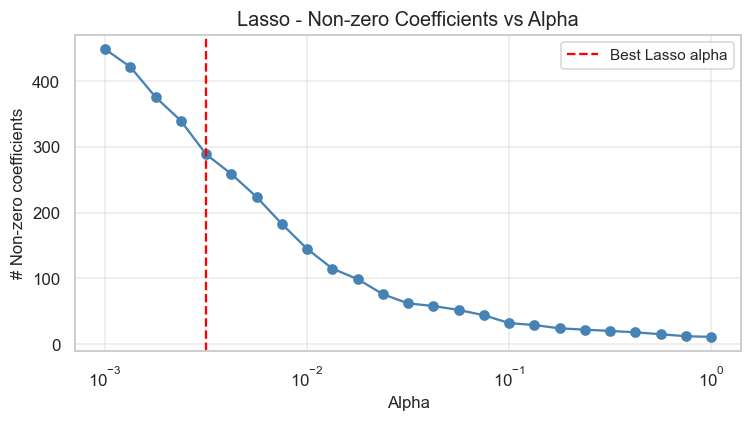

Ridge best alpha: 31.622776601683793


In [19]:
preprocess_path = make_preprocess()
X_train_p = preprocess_path.fit_transform(X_train)

alphas_path = np.logspace(-3, 0, 25)
nonzero = []
for a in alphas_path:
    lasso_tmp = Lasso(alpha=a, max_iter=5000)
    lasso_tmp.fit(X_train_p, y_train)
    nonzero.append(np.sum(lasso_tmp.coef_ != 0))

plt.figure(figsize=(7, 4))
plt.semilogx(alphas_path, nonzero, marker='o', color='steelblue')
plt.axvline(lasso.named_steps['model'].alpha_, color='red', linestyle='--', label='Best Lasso alpha')
plt.title('Lasso - Non-zero Coefficients vs Alpha')
plt.xlabel('Alpha'); plt.ylabel('# Non-zero coefficients'); plt.legend(); plt.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()
print('Ridge best alpha:', ridge.named_steps['model'].alpha_)


In [20]:
lasso_feature_names = get_feature_names(lasso.named_steps['preprocess'])
lasso_coefs = lasso.named_steps['model'].coef_
zero_mask = np.isclose(lasso_coefs, 0.0)
zeroed = np.array(lasso_feature_names)[zero_mask]

print('Zeroed features by Lasso:', len(zeroed))
print(zeroed[:30])


Zeroed features by Lasso: 355
['departure_hour' 'is_weekend' 'is_low_visibility'
 'airline_AEGEAN AIRLINES' 'airline_AER LINGUS' 'airline_AIR ALBANIA'
 'airline_AIR ARABIA' 'airline_AIR ARABIA ABU DHABI'
 'airline_AIR ARABIA EGYPT' 'airline_AIR BALTIC' 'airline_AIR CAIRO'
 'airline_AIR FRANCE' 'airline_AIR HAMBURG' 'airline_AIR NOSTRUM'
 'airline_AIR SUNSHINE' 'airline_AJET' 'airline_ALANNA'
 'airline_ARIANA AFGHAN AIRLINES' 'airline_ASTRA AIRLINES'
 'airline_AUSTRIAN AIRLINES' 'airline_AVION EXPRESS'
 'airline_AZIMUTH AIRLINES' 'airline_BADR AIRLINES' 'airline_BELAVIA'
 'airline_BIMAN BANGLADESH AIRLINES' 'airline_BRINDABELLA AIRLINES'
 'airline_BRITISH AIRWAYS' 'airline_BRUSSELS AIRLINES'
 'airline_CORENDON AIRLINES EUROPE' 'airline_CORENDON DUTCH AIRLINES']


**Lasso insight:** As expected, Lasso performs aggressive feature selection by completely removing a massive number of weak one-hot categories, specifically specific airlines and destination airports. Interestingly, it also zeroed out general features like `departure_hour` and `is_low_visibility`, suggesting it found stronger predictive value in other remaining variables. In contrast, Ridge regression keeps all features in the model but shrinks their coefficients smoothly.

---
## 8. Model Comparison


In [21]:
comp = pd.DataFrame.from_dict(model_scores, orient='index').reset_index()
comp = comp.rename(columns={'index': 'Model'})
comp = comp.sort_values('Val_R2', ascending=False)
print('=== Model Comparison Table ===')
print(comp.round(4).to_string(index=False))
comp


=== Model Comparison Table ===
               Model  Train_R2  Val_R2  Test_R2  Test_RMSE  Test_MAE
               Ridge    0.0764  0.0031  -0.0074    61.2773   22.8889
         Multiple LR    0.0788  0.0026  -0.0066    61.2540   22.9415
               Lasso    0.0750  0.0018  -0.0087    61.3179   22.7985
  Polynomial (deg 3)    0.0776  0.0006  -0.0042    61.1815   22.9695
Baseline (simple LR)    0.0292 -0.0192  -0.0000    61.0523   23.5876


,Model,Train_R2,Val_R2,Test_R2,Test_RMSE,Test_MAE
3,Ridge,0.076374,0.003123,-0.007387,61.277303,22.888910
1,Multiple LR,0.078800,0.002584,-0.006620,61.253971,22.941522
4,Lasso,0.075002,0.001799,-0.008723,61.317939,22.798540
2,Polynomial (deg 3),0.077615,0.000620,-0.004238,61.181477,22.969498
0,Baseline (simple LR),0.029224,-0.019227,-0.000002,61.052285,23.587550


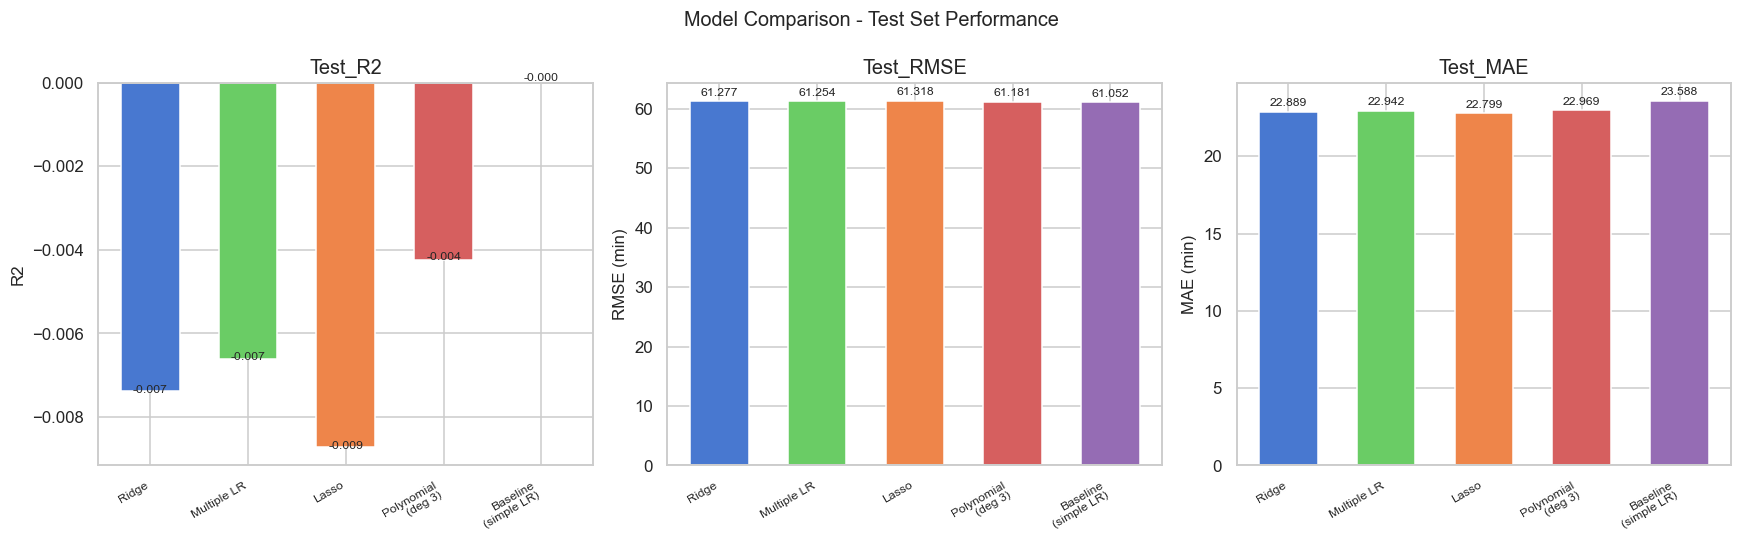

In [22]:
x = np.arange(len(comp))
pal = ['#4878d0','#6acc65','#ee854a','#d65f5f','#956cb4','#8c8c8c']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, ylab in zip(axes, ['Test_R2', 'Test_RMSE', 'Test_MAE'], ['R2', 'RMSE (min)', 'MAE (min)']):
    bars = ax.bar(x, comp[col], color=pal[:len(x)], edgecolor='white', width=0.6)
    ax.set_title(col); ax.set_ylabel(ylab); ax.set_xticks(x)
    ax.set_xticklabels([m.replace(' (', '\n(') for m in comp['Model']], rotation=30, ha='right', fontsize=8)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height()*1.01, f"{b.get_height():.3f}", ha='center', va='bottom', fontsize=8)
plt.suptitle('Model Comparison - Test Set Performance', fontsize=13); plt.tight_layout(); plt.show()


In [27]:
best_row = comp.iloc[0]
best_name = best_row['Model']
print('Best model by validation R2:', best_name)
print(f"Test R2   : {best_row['Test_R2']:.4f}")
print(f"Test RMSE : {best_row['Test_RMSE']:.4f}")
print(f"Test MAE  : {best_row['Test_MAE']:.4f}")


Best model by validation R2: Ridge
Test R2   : -0.0074
Test RMSE : 61.2773
Test MAE  : 22.8889


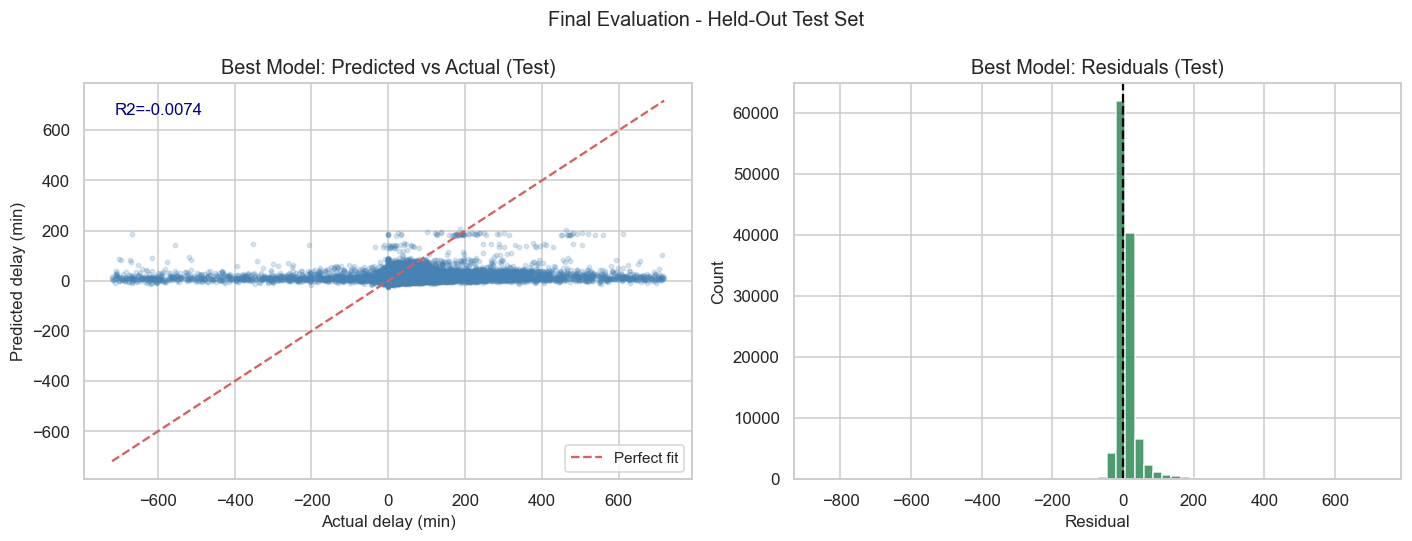

Final test  R2=-0.0074  RMSE=61.2773  MAE=22.8889


In [26]:
best_model = model_store[best_name]
yp_best = best_model.predict(X_test)
best_metrics = regression_metrics(y_test, yp_best)
r2f = best_metrics['r2']; rmsef = best_metrics['rmse']; maef = best_metrics['mae']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, yp_best, alpha=0.2, s=8, color='steelblue')
lo, hi = y_test.min(), y_test.max()
axes[0].plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Perfect fit')
axes[0].set_title('Best Model: Predicted vs Actual (Test)')
axes[0].set_xlabel('Actual delay (min)'); axes[0].set_ylabel('Predicted delay (min)'); axes[0].legend()
axes[0].text(0.05, 0.92, f"R2={r2f:.4f}", transform=axes[0].transAxes, fontsize=11, color='navy')
res_f = y_test - yp_best
axes[1].hist(res_f, bins=60, color='seagreen', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', lw=1.5, linestyle='--')
axes[1].set_title('Best Model: Residuals (Test)'); axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Count')
plt.suptitle('Final Evaluation - Held-Out Test Set', fontsize=13); plt.tight_layout(); plt.show()
print(f'Final test  R2={r2f:.4f}  RMSE={rmsef:.4f}  MAE={maef:.4f}')


**Best model justification: Ridge (by validation R2)**
* **Selection rule:** Model choice is based on validation performance to avoid test-set leakage. Ridge has the highest Val R2, so it is the most defensible pick.
* **Bias-variance tradeoff:** Ridge reduces variance from high-cardinality one-hot features by shrinking coefficients, which tends to generalize better than unregularized models.
* **Test note:** On the test set, the Baseline (simple LR) achieves the best RMSE and highest (least negative) R2, but this is reported for final evaluation rather than selection.

---
## 9. Interpretation & Reflection

**What do the results tell us about the problem?**

Linear models with the current features have weak explanatory power. Ridge is the best choice by validation, while the baseline performs slightly better on the test set, suggesting a noisy, hard-to-predict target with limited linear signal.

**Are predictions good enough to be useful?**

Not yet. Test $R^2 \le 0$ means no real explanatory power, and Test RMSE around 61 minutes is too large for reliable decisions.

**Main sources of error:**
* Overfitting: High-cardinality features add noise and inflate variance
* Non-linearity: Linear models miss interactions and thresholds
* Heavy tails: Extreme delays dominate error metrics
* Zero-inflation: Many on-time flights distort the distribution

**How will these findings guide P3?**
1. Use tree-based models to capture non-linear patterns
2. Reassess high-cardinality features (grouping or target encoding)
3. Try models/losses that handle skewed, heavy-tailed targets